## Setting

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Importing Dependencies

In [2]:
!pip install nltk
!pip install -U pandas-profiling
!pip install pydantic==1.10.10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.5/357.5 kB 35.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 36.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.5/679.5 kB 52.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 34.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 75.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.1 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=25846e7888cb95a42e71dd43504549664a0245a3c501f251e6668fd410e85947
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attempting unin

In [3]:
import string
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
# import ydata_profiling

import numpy as np

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer


from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer, normalize

from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.cluster import SpectralClustering

from wordcloud import WordCloud

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


### Data Load & EDA

In [4]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/Sample_Dataset.csv", encoding = 'cp949')
# data.profile_report()

## STEP 1 : Data Claeaning

In [5]:
# delected data where the abstract or title information was missing or was a duplicate
data.dropna(subset=['Abstract'], inplace=True)

data.drop_duplicates(subset=['Article Title'], inplace=True)
data.drop_duplicates(subset=['Abstract'], inplace=True)

print("총 Document 수 :", data.shape[0])

총 Document 수 : 989


In [6]:
# make corpus
def combine_3rd_columns(col_1, col_2, col_3):

    result = col_1

    if not pd.isna(col_2):
        result += " " + str(col_2)

    if not pd.isna(col_3):
        result += " " + str(col_3)

    return result

data["text"] = data.apply(lambda x: combine_3rd_columns(x['Article Title'], x['Abstract'], x['Author Keywords']), axis=1)

df = data.loc[:, ['text', 'Article Title']]
df.head()

,text,Article Title
0,The development for Internet of Things smart h...,The development for Internet of Things smart h...
1,Research of Smart Home Service Platform Based ...,Research of Smart Home Service Platform Based ...
2,SHSM: A Service Middleware for Smart Home Ther...,SHSM: A Service Middleware for Smart Home
3,A Middleware of IoT-based Smart Home Based on ...,A Middleware of IoT-based Smart Home Based on ...
4,A Framework of Smart-Home Service for Elderly'...,A Framework of Smart-Home Service for Elderly'...


#### Data preprocessing

In [7]:
def preprocess_text(text):

    # Tokenize the text (split it into individual words)
    words = nltk.word_tokenize(text)

    # Initialize lists to hold the original and lemmatized words
    original_words = []
    lemmatized_words = []

    words = [token for token in words if token not in string.punctuation]

    for word in words:
        word = word.lower()

        if word not in stop_words and not word.isdigit() :
            lemma = lemmatizer.lemmatize(word)
            lemmatized_words.append(lemma)

            if word != lemma :
                original_words.append({word : lemma})

    # Remove numbers and rejoin the tokens into a string
    processed_text = ' '.join([token for token in lemmatized_words])

    return processed_text, original_words

# Apply the function to the 'text' column of df
df['processed_data'] = df['text'].apply(preprocess_text)

# Split the processed_data column into two separate columns: one for processed text and one for lemma pairs.
df[['corpus', 'lemma_pairs']] = pd.DataFrame(df['processed_data'].tolist(), index=df.index)

# Drop the now redundant 'processed_data' column.
df.drop(columns=['processed_data'], inplace=True)

df.head()

,text,Article Title,corpus,lemma_pairs
0,The development for Internet of Things smart h...,The development for Internet of Things smart h...,development internet thing smart home service ...,"[{'things': 'thing'}, {'things': 'thing'}, {'t..."
1,Research of Smart Home Service Platform Based ...,Research of Smart Home Service Platform Based ...,research smart home service platform based mob...,"[{'projects': 'project'}, {'products': 'produc..."
2,SHSM: A Service Middleware for Smart Home Ther...,SHSM: A Service Middleware for Smart Home,shsm service middleware smart home emerges inc...,"[{'obstacles': 'obstacle'}, {'resources': 'res..."
3,A Middleware of IoT-based Smart Home Based on ...,A Middleware of IoT-based Smart Home Based on ...,middleware iot-based smart home based service ...,"[{'presents': 'present'}, {'problems': 'proble..."
4,A Framework of Smart-Home Service for Elderly'...,A Framework of Smart-Home Service for Elderly'...,framework smart-home service elderly 's biophi...,"[{'services': 'service'}, {'supports': 'suppor..."


##### Customized rules : do not lemmatize “glasses” to “glass”



In [8]:
check_list = df.loc[:, ['lemma_pairs']]
df = df.loc[:, ['corpus', 'Article Title']]

combined_list = check_list['lemma_pairs'].sum()

def remove_duplicates(lst):
    result = []
    for item in lst:
        if item not in result:
            result.append(item)
    return result

unique_ordered_list  = remove_duplicates(combined_list)

keys, values = [], []

for d in unique_ordered_list:
    for key, value in d.items():
        keys.append(key)
        values.append(value)

checks = pd.DataFrame({'Key': keys, 'Value': values})
checks.drop_duplicates(subset=['Key'], inplace=True)
checks.drop_duplicates(subset=['Value'], inplace=True)

def check_meaning(word):
    singular = wordnet.synsets(word)
    plural = wordnet.synsets(word + 's')

    if singular and plural:
        if singular[0].definition() != plural[0].definition():
            return (True, f"'{word}': {singular[0].definition()}", f"'{word}s': {plural[0].definition()}")

    return (False, None, None)

checks['is_different'], checks['singular_def'], checks['plural_def'] = zip(*checks['Value'].map(check_meaning))

checks[checks['is_different']].to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized_1.csv', index=False)

In [9]:
df = df.loc[:, ['corpus', 'Article Title']]
df.dropna(subset=['corpus'], inplace=True)

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 989
현재 word-feature 갯수: 7755


###  Word-feature - finding core vector space

#### word_featuring_1) Deciding on the number of keywords to be selected from each item

In [10]:
# visualization function
from matplotlib.ticker import FuncFormatter

def plot_keywords(x, y, y_label, title):
    plt.figure(figsize=(10,6))

    plt.plot(x, y,  marker='o', color = 'b')

    plt.gca().invert_xaxis()

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

    # K formatter
    k_formatter = FuncFormatter(lambda x, pos: f'K{x}')

    # Apply the formatter
    plt.gca().xaxis.set_major_formatter(k_formatter)

    plt.xlabel('Number of selected top keywords from each data')
    plt.ylabel(y_label)

    for i in [4, 5]:
        if i in x:
            index = x.index(i)
            plt.plot(i, y[index], marker='o', color='r')

    plt.title(title)
    plt.show()

##### Metric 1 : Mean of the TF-IDF scores of a word-feature across data

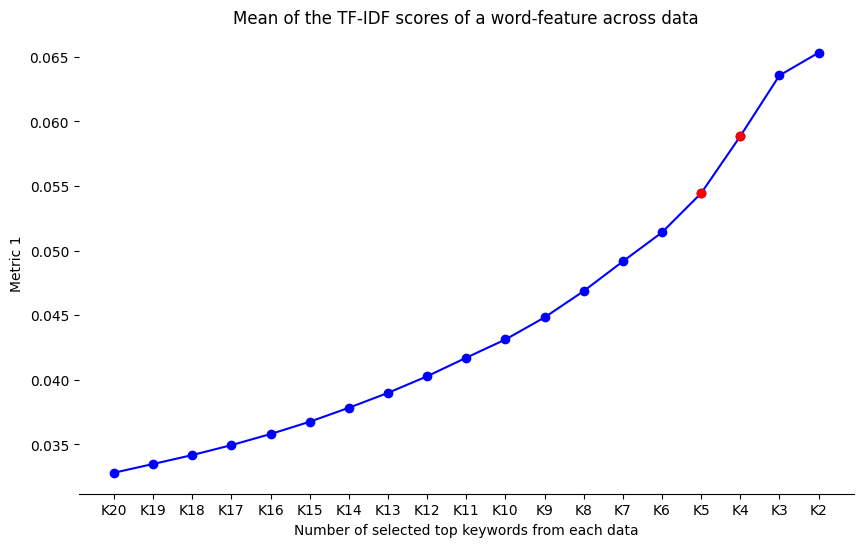

In [11]:
mean_tfidf_scores = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix.mean(axis=0)).ravel())[::-1][:count]
    mean_score = tfidf_matrix[:, top_keywords_indices].mean()
    mean_tfidf_scores.append(mean_score)

plot_keywords(keyword_counts, mean_tfidf_scores, 'Metric 1',  'Mean of the TF-IDF scores of a word-feature across data')

##### Metric 2 : Mean of the cosine similarities of a word-feature to other features

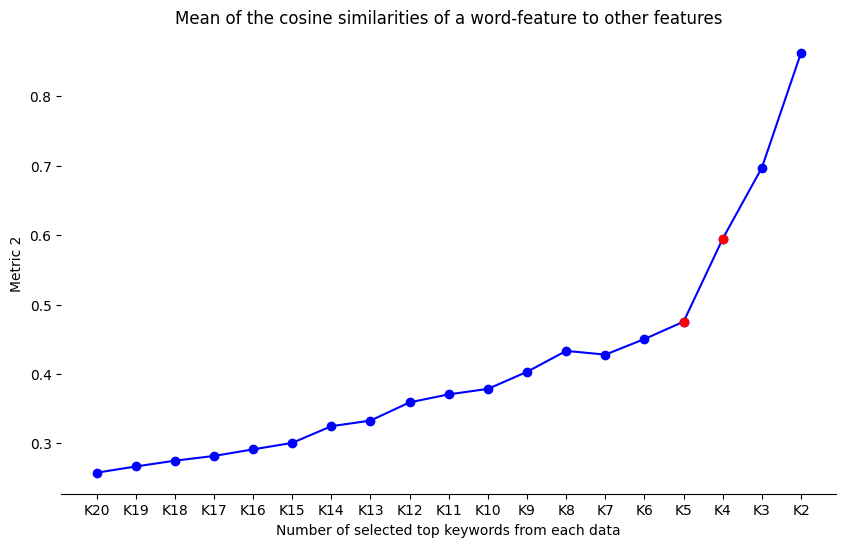

In [12]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    similarity_matrix = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices])
    mean_similarity = np.mean(similarity_matrix[np.triu_indices(count, k=1)])
    mean_cosine_similarities.append(mean_similarity)

plot_keywords(keyword_counts, mean_cosine_similarities,'Metric 2', 'Mean of the cosine similarities of a word-feature to other features')

##### Metric 3 : Cosine similarity between a word-feature and the centroid of features

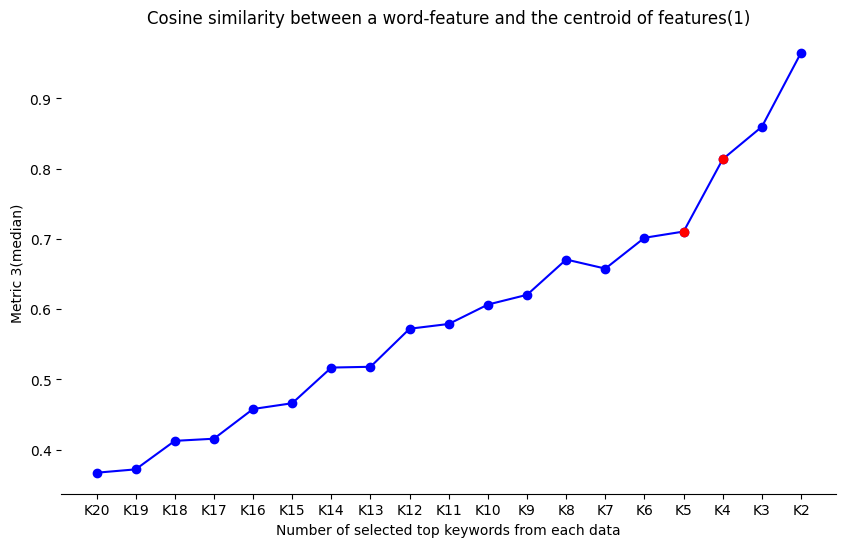

In [13]:
# meadian 사용
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.toarray().T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    centroid_vector = np.median(tfidf_matrix_transposed[top_keywords_indices], axis=0).reshape(1, -1)
    similarity_to_centroid = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices], centroid_vector)
    mean_similarity_to_centroid = similarity_to_centroid.mean()
    mean_cosine_similarities.append(mean_similarity_to_centroid)

plot_keywords(keyword_counts, mean_cosine_similarities, "Metric 3(median)", "Cosine similarity between a word-feature and the centroid of features(1)")

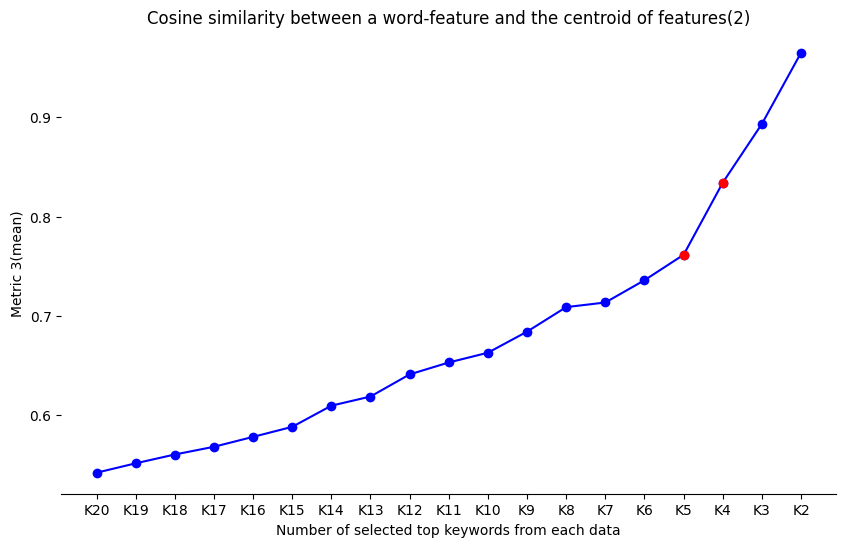

In [14]:
# 평균 사용
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.toarray().T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    centroid_vector = np.asarray(tfidf_matrix_transposed[top_keywords_indices].mean(axis=0)).reshape(1, -1)
    similarity_to_centroid = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices], centroid_vector)
    mean_similarity_to_centroid = similarity_to_centroid.mean()
    mean_cosine_similarities.append(mean_similarity_to_centroid)

plot_keywords(keyword_counts, mean_cosine_similarities, "Metric 3(mean)", "Cosine similarity between a word-feature and the centroid of features(2)")

##### Metric 4 : Mean of the dot product scores of a word-feature to other features

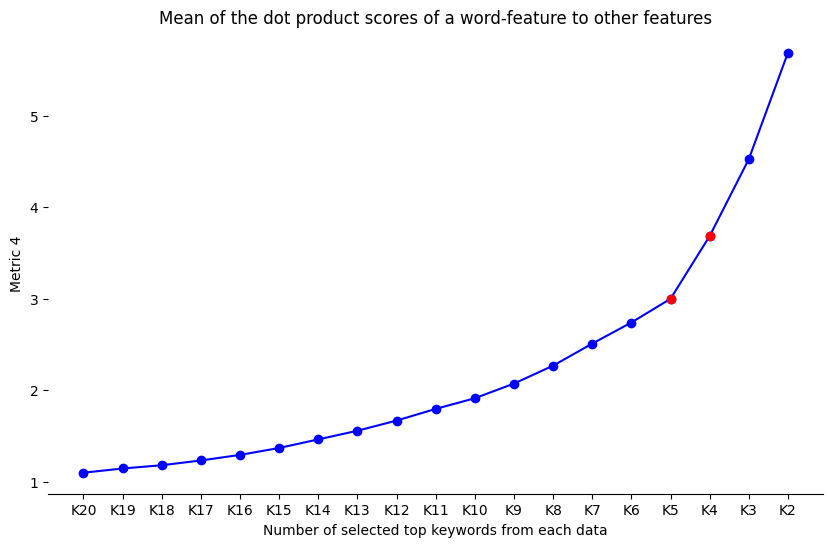

In [15]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T

mean_dot_product_scores = []
keyword_counts = list(range(20, 1, -1))

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    dot_product_matrix = np.dot(tfidf_matrix_transposed[top_keywords_indices], tfidf_matrix_transposed[top_keywords_indices].T)
    mean_dot_product_score = np.mean(dot_product_matrix[np.triu_indices(count, k=1)])
    mean_dot_product_scores.append(mean_dot_product_score)

plot_keywords(keyword_counts, mean_dot_product_scores,"Metric 4", "Mean of the dot product scores of a word-feature to other features")

##### Metric 5 : LDA score of a word-feature for the single topic of entire data set

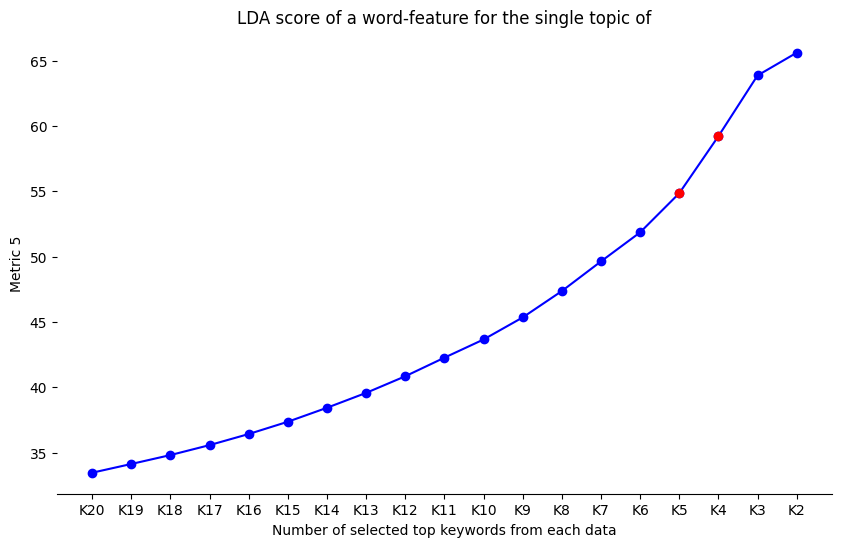

In [16]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])

lda_model = LatentDirichletAllocation(n_components=1, random_state=42)
lda_model.fit(tfidf_matrix)

mean_lda_scores = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = lda_model.components_.argsort()[0, -count:]
    mean_lda_score = lda_model.components_[0, top_keywords_indices].mean()
    mean_lda_scores.append(mean_lda_score)

plot_keywords(keyword_counts, mean_lda_scores,"Metric 5", "LDA score of a word-feature for the single topic of")

##### Result

In [17]:
# Items 당 상위 4개의 단어 선택 - Type 3 제거
top_keywords_per_document = []
feature_names = tfidf_vectorizer.get_feature_names_out()

for i in range(len(df)):
    tfidf_scores = zip(feature_names, tfidf_matrix[i].toarray()[0])
    sorted_tfidf_scores = sorted(tfidf_scores,key=lambda x: x[1], reverse=True)

    top_keywords_per_document.append([keyword for keyword,_ in sorted_tfidf_scores[:5]])

# 전체 데이터셋에서 적어도 2번 이상 나온 키워드 추출하기 - Type 1 제거
all_keywords=[keyword for document in top_keywords_per_document for keyword in document]
selected_keywords=list(set(keyword for keyword in all_keywords if all_keywords.count(keyword) >=2))

print("현재 word-feature 갯수:",len(selected_keywords))

checking = pd.DataFrame(selected_keywords, columns = ['keyword'])
checking.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/output_2.csv', index=False)

현재 word-feature 갯수: 734


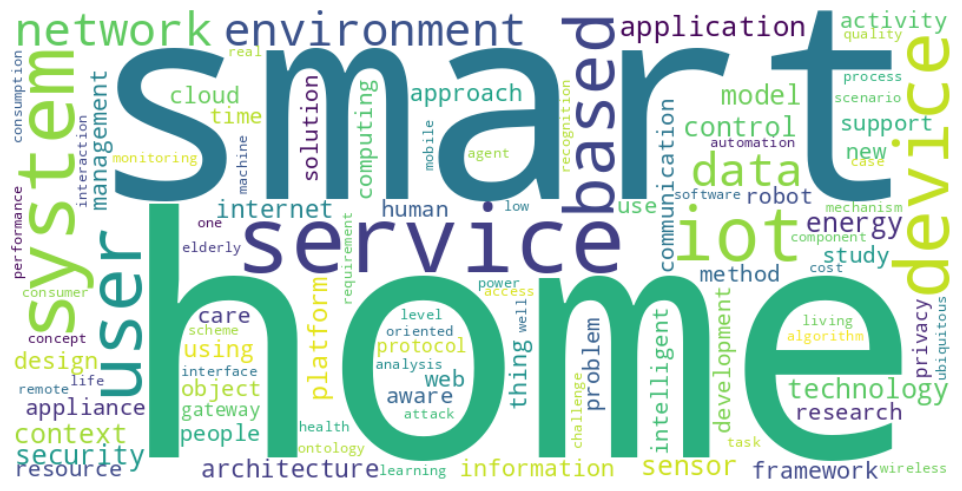

In [18]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
X = vectorizer.fit_transform(df['corpus'])

tfidf_sum = np.sum(X.toarray(), axis=0)


word_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), tfidf_sum))
top_100_words = sorted(word_tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:100]
top_100_wordcloud_dict = dict(top_100_words)

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color = 'white',).generate_from_frequencies(top_100_wordcloud_dict)

# 결과 출력
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.tight_layout(pad=0)
plt.axis('off')
plt.show()

#### word_featuring_2) Clustering based on Gaussian mixture model (GMM)

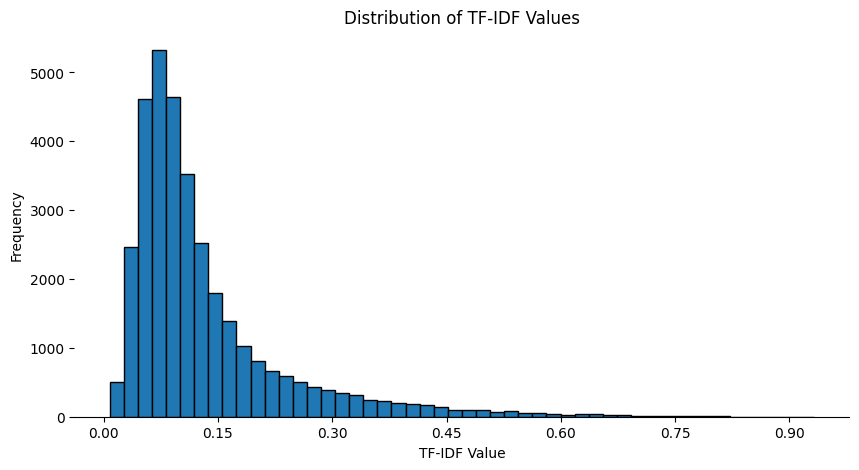

In [19]:
# Checked distribution of words : TF-IDF
tfidf_values = X.data

plt.figure(figsize=(10, 5))
plt.hist(tfidf_values, bins=50, edgecolor='black')

plt.xlabel('TF-IDF Value')
plt.ylabel('Frequency')
plt.title('Distribution of TF-IDF Values')


plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

In [20]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
X = vectorizer.fit_transform(df['corpus'])
feature_names = vectorizer.get_feature_names_out()
tfidf_matrix_transposed = X.T.toarray()

In [21]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
feature_names = vectorizer.get_feature_names_out()

tfidf_matrix = vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

two_keywords_set = None

for i in range(10):

    gmm = GaussianMixture(n_components=100)
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    max_data_pointer_cluster_label = df_clustered_keywords['cluster'].value_counts().idxmax()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'] == max_data_pointer_cluster_label]['keyword'].values.tolist()
    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

    if two_keywords_set is None:
        two_keywords_set=set(max_data_pointer_cluster)

    else:
        two_keywords_set=two_keywords_set.union(set(max_data_pointer_cluster))

extract_keywords_list = list(two_keywords_set)
select_keywords_list = [keyword for keyword in selected_keywords if keyword not in extract_keywords_list]

print(" ")
print("합집합")
print("Type2로 선정되 단어 갯수", len(select_keywords_list))
print("Type1&Type3로 추출된 단어 갯수 :", len(extract_keywords_list))

1번째 시행 클러스터 속 데이터 갯수: 472
2번째 시행 클러스터 속 데이터 갯수: 540
3번째 시행 클러스터 속 데이터 갯수: 524
4번째 시행 클러스터 속 데이터 갯수: 476
5번째 시행 클러스터 속 데이터 갯수: 554
6번째 시행 클러스터 속 데이터 갯수: 492
7번째 시행 클러스터 속 데이터 갯수: 560
8번째 시행 클러스터 속 데이터 갯수: 534
9번째 시행 클러스터 속 데이터 갯수: 523
10번째 시행 클러스터 속 데이터 갯수: 484
 
합집합
Type2로 선정되 단어 갯수 80
Type1&Type3로 추출된 단어 갯수 : 654


In [22]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
feature_names = vectorizer.get_feature_names_out()

tfidf_matrix = vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

two_keywords_set = None

for i in range(10):

    gmm = GaussianMixture(n_components=100)
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    max_data_pointer_cluster_label = df_clustered_keywords['cluster'].value_counts().idxmax()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'] == max_data_pointer_cluster_label]['keyword'].values.tolist()
    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

    if two_keywords_set is None:
        two_keywords_set=set(max_data_pointer_cluster)

    else:
        two_keywords_set=two_keywords_set.intersection(set(max_data_pointer_cluster))

extract_keywords_list = list(two_keywords_set)
select_keywords_list = [keyword for keyword in selected_keywords if keyword not in extract_keywords_list]

print(" ")
print("교집합")
print("Type2로 선정되 단어 갯수", len(select_keywords_list))
print("Type1&Type3로 추출된 단어 갯수 :", len(extract_keywords_list))

1번째 시행 클러스터 속 데이터 갯수: 510
2번째 시행 클러스터 속 데이터 갯수: 499
3번째 시행 클러스터 속 데이터 갯수: 553
4번째 시행 클러스터 속 데이터 갯수: 550
5번째 시행 클러스터 속 데이터 갯수: 522
6번째 시행 클러스터 속 데이터 갯수: 506
7번째 시행 클러스터 속 데이터 갯수: 520
8번째 시행 클러스터 속 데이터 갯수: 537
9번째 시행 클러스터 속 데이터 갯수: 513
10번째 시행 클러스터 속 데이터 갯수: 541
 
교집합
Type2로 선정되 단어 갯수 427
Type1&Type3로 추출된 단어 갯수 : 307


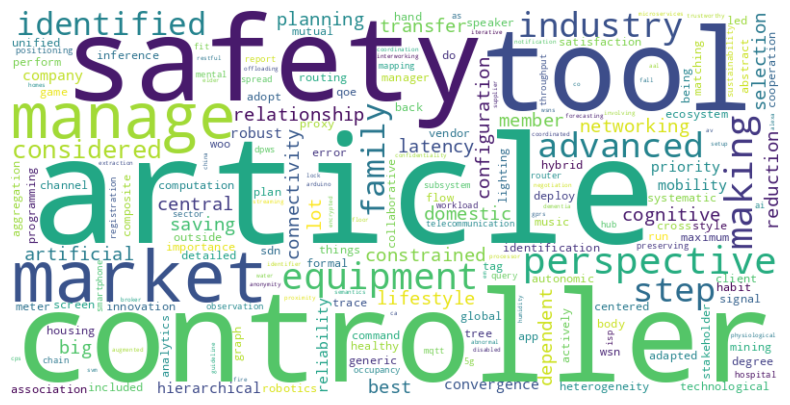

In [23]:
vectorizer = TfidfVectorizer(vocabulary=extract_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
avg_tfidf_values = tfidf_matrix.mean(axis=0).A1
keyword_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), avg_tfidf_values))

for word, value in keyword_tfidf_dict.items():
    if np.isnan(value):
        print(f"'{word}' has a TF-IDF value of NaN.")
        keyword_tfidf_dict[word] = 0

wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(frequencies=keyword_tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

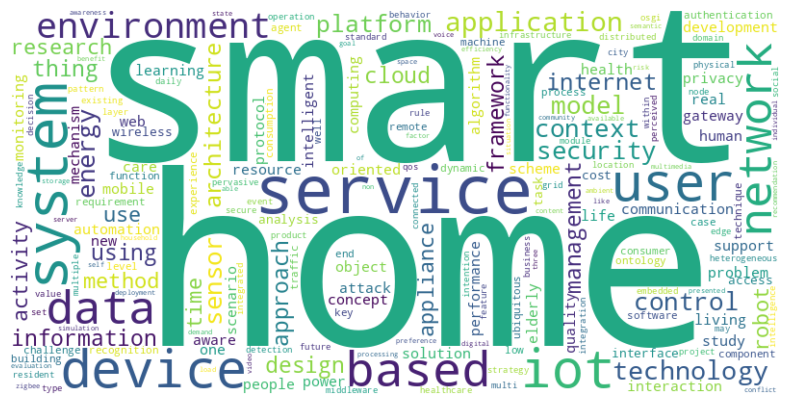

In [24]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
avg_tfidf_values = tfidf_matrix.mean(axis=0).A1
keyword_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), avg_tfidf_values))

for word, value in keyword_tfidf_dict.items():
    if np.isnan(value):
        print(f"'{word}' has a TF-IDF value of NaN.")
        keyword_tfidf_dict[word] = 0


wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(frequencies=keyword_tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [25]:
checking_1= pd.DataFrame(select_keywords_list, columns = ['keyword'])
checking_1.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/select_output_2.csv', index=False)

checking_2 = pd.DataFrame(extract_keywords_list, columns = ['keyword'])
checking_2.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/extract_output_2.csv', index=False)

### Eliminated outliers by calculating the cosine similarities

In [26]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

cosine_sim = cosine_similarity(tfidf_df) - np.eye(tfidf_df.shape[0])

mean_cosine_sim = np.mean(cosine_sim, axis=1)

df_cosine_sim = pd.DataFrame(mean_cosine_sim, columns=['Mean Cosine Similarity'], index=df.index)
df_sorted = df_cosine_sim.sort_values(by='Mean Cosine Similarity')

bottom_100_indices_and_values = df_sorted.head(100)

bottom_100_titles = df.loc[bottom_100_indices_and_values.index, 'Article Title']
bottom_100_titles.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/bottom_100_titles.csv', index=False)

## STEP 2 : Descriptive analysis

## STEP 3 : Unsupervised machine learning

### Principal component analysis(PCA)

Number of components for 95% variance: 295


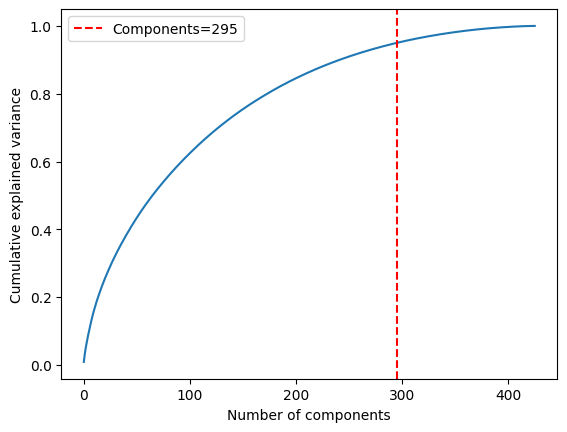

In [27]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

X = tfidf_matrix

svd = TruncatedSVD(n_components=X.shape[1]-1)
svd.fit(X)

cumulative_explained_variance = np.cumsum(svd.explained_variance_ratio_)

n_components = np.where(cumulative_explained_variance > 0.95)[0][0]

print(f"Number of components for 95% variance: {n_components}")

plt.plot(cumulative_explained_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axvline(x=n_components, color='r', linestyle='--', label=f'Components={n_components}')
plt.legend()
plt.show()

### Spectral Clustering

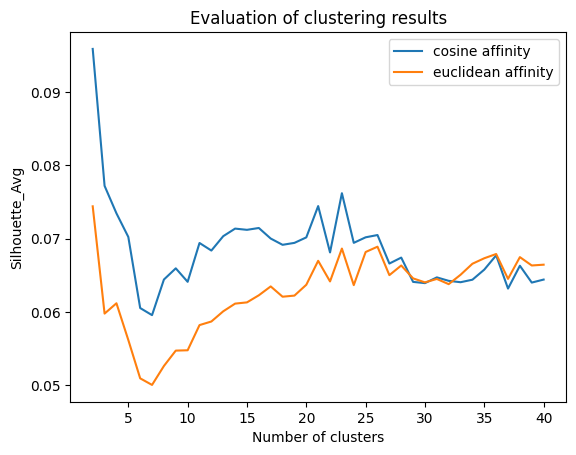

In [29]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

svd = TruncatedSVD(n_components=n_components)
reduced_data = svd.fit_transform(tfidf_matrix)

metrics = ['cosine', 'euclidean']

cluster_range = range(2, 41)

results = {}

for metric in metrics:
    results[metric] = []

    for n_clusters in cluster_range:
        silhouette_avg_list = []

        # 유사도/거리 행렬 생성
        if metric == 'cosine':
            similarity_matrix = cosine_similarity(reduced_data)
        elif metric == 'euclidean':
            similarity_matrix = euclidean_distances(reduced_data)

        # Spectral Clustering 실행 (10번 반복)
        for _ in range(10):
            sc = SpectralClustering(n_clusters=n_clusters, random_state=0).fit(reduced_data)
            labels=sc.labels_

            silhouette_avg_list.append(silhouette_score(similarity_matrix, labels))

        results[metric].append(np.mean(silhouette_avg_list))

for metric in metrics:
    plt.plot(cluster_range, results[metric], label=f'{metric} affinity')

plt.title('Evaluation of clustering results')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_Avg')
plt.legend()
plt.show()

### Simple analysis

### Topic modeling